In [ ]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Load Dataset
df=pd.read_csv("/house_price_dataset.csv")
df.head()

,area_sqft,bedrooms,bathrooms,age_years,parking_spaces,price
0,3774,4,2,3,2,611362
1,1460,5,2,8,0,265630
2,1894,2,2,5,1,323350
3,1730,4,4,1,2,324974
4,1695,2,3,16,2,277830


In [ ]:
display(df.describe())

,area_sqft,bedrooms,bathrooms,age_years,parking_spaces,price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2347.620000,3.030000,2.468000,14.740000,0.978000,378540.042000
std,967.729667,1.459232,1.104271,8.756126,0.809213,148984.443762
min,601.000000,1.000000,1.000000,0.000000,0.000000,75329.000000
25%,1555.750000,2.000000,1.000000,7.000000,0.000000,255271.750000
50%,2318.500000,3.000000,2.000000,14.500000,1.000000,369706.000000
75%,3199.500000,4.000000,3.000000,23.000000,2.000000,507399.500000
max,3997.000000,5.000000,4.000000,29.000000,2.000000,663267.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   area_sqft       500 non-null    int64
 1   bedrooms        500 non-null    int64
 2   bathrooms       500 non-null    int64
 3   age_years       500 non-null    int64
 4   parking_spaces  500 non-null    int64
 5   price           500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


In [ ]:
#check missing values
df.isnull().sum()

,0
area_sqft,0
bedrooms,0
bathrooms,0
age_years,0
parking_spaces,0
price,0


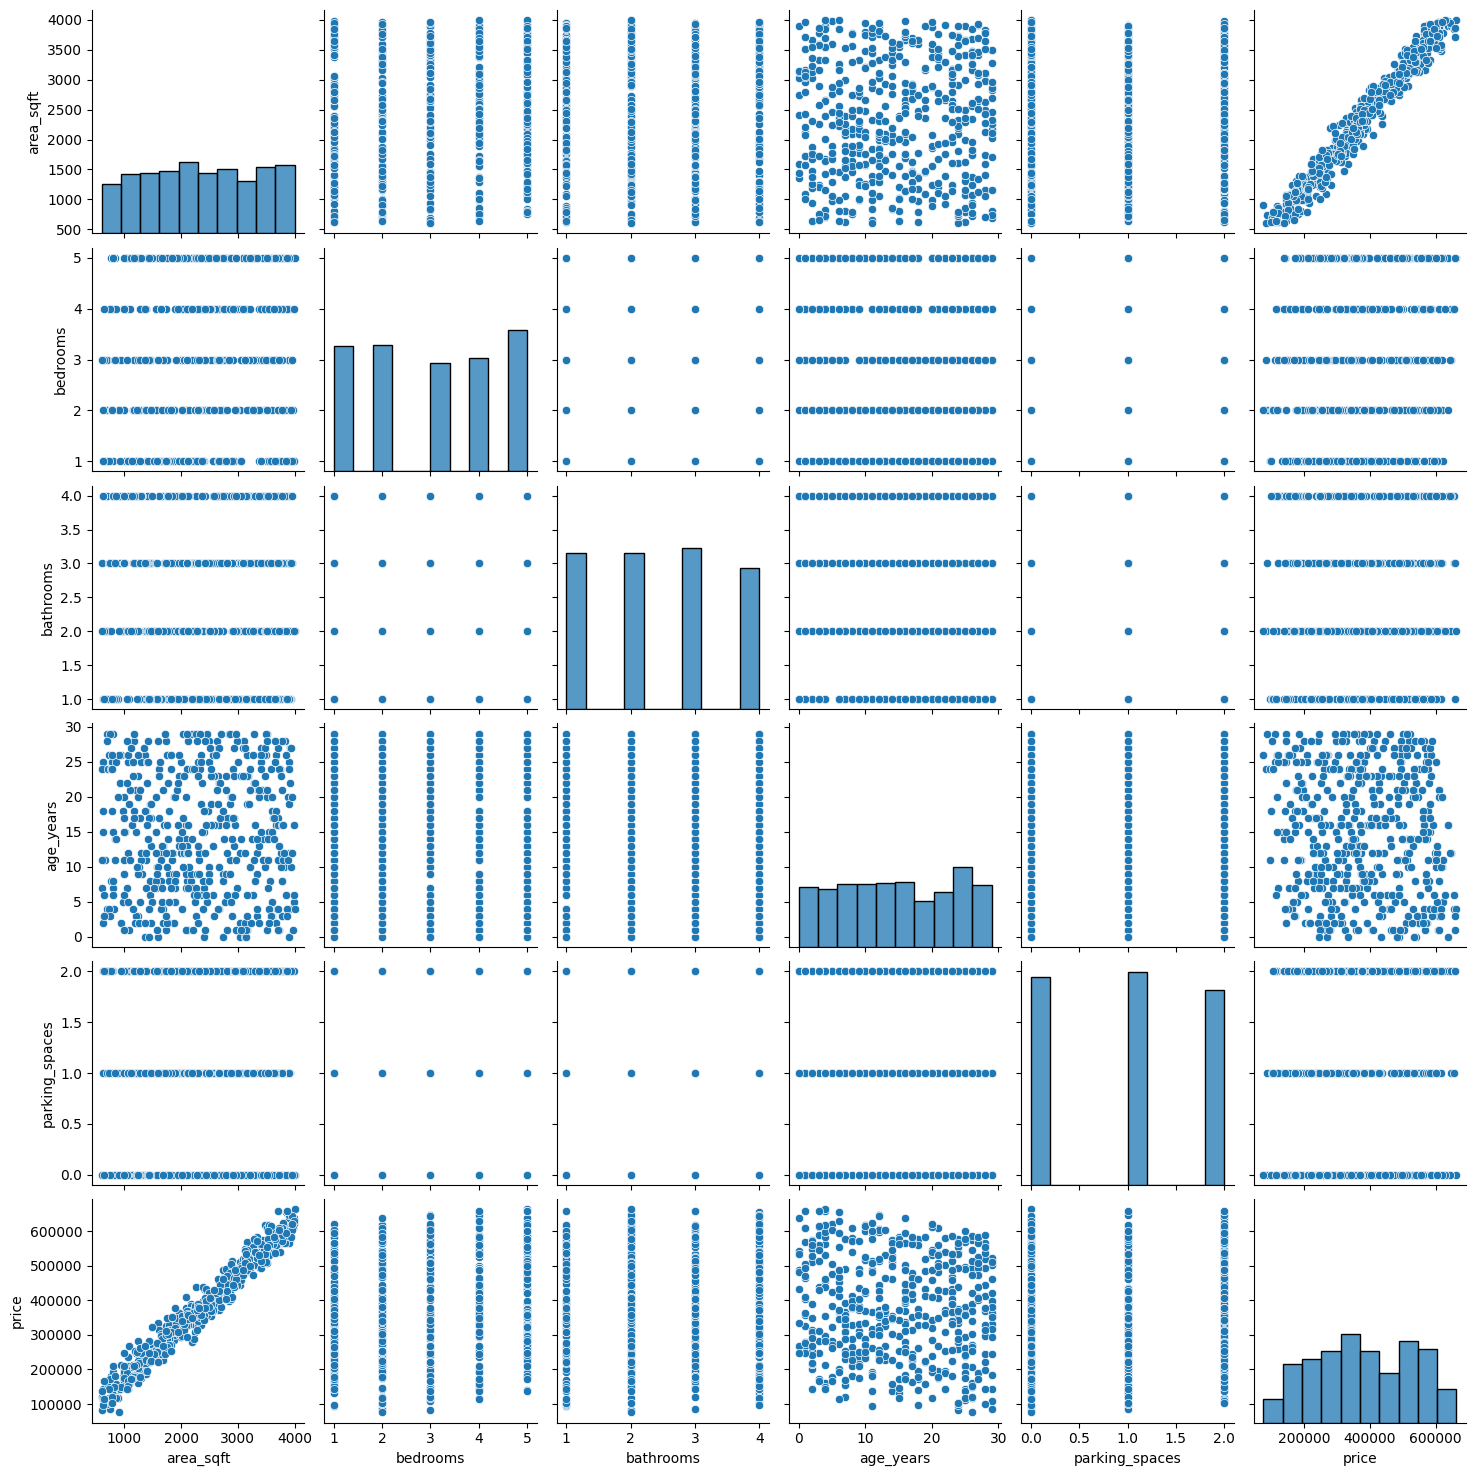

In [ ]:
#EDA
sns.pairplot(df)
plt.show()

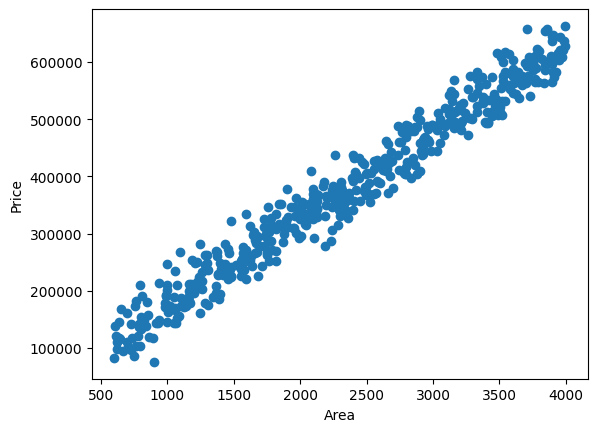

In [ ]:
plt.scatter(df['area_sqft'],df['price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

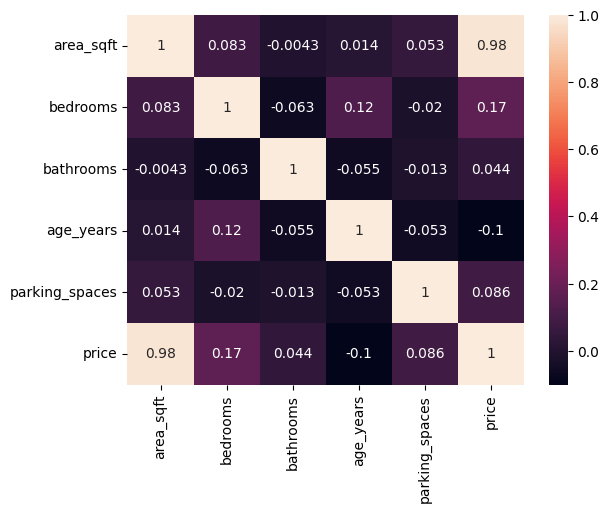

In [ ]:
sns.heatmap(df.corr(),annot=True)
plt.show()

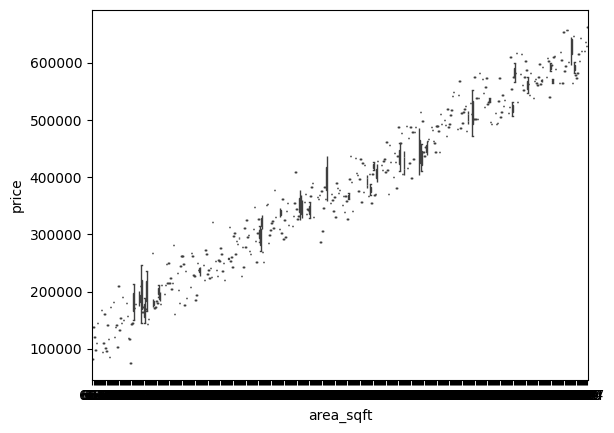

In [ ]:
sns.boxplot(x='area_sqft', y='price', data=df)
plt.show()

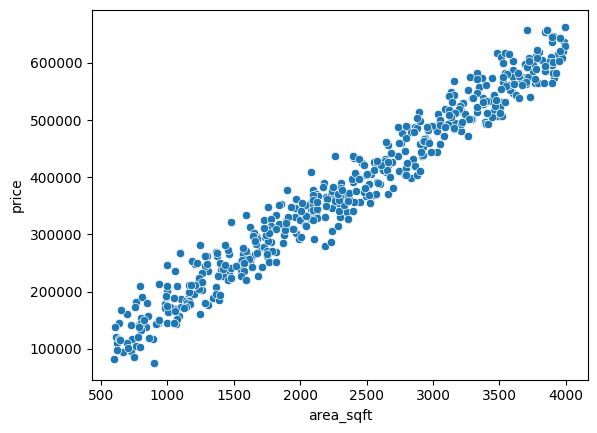

In [ ]:
sns.scatterplot(x='area_sqft', y='price', data=df)
plt.show()

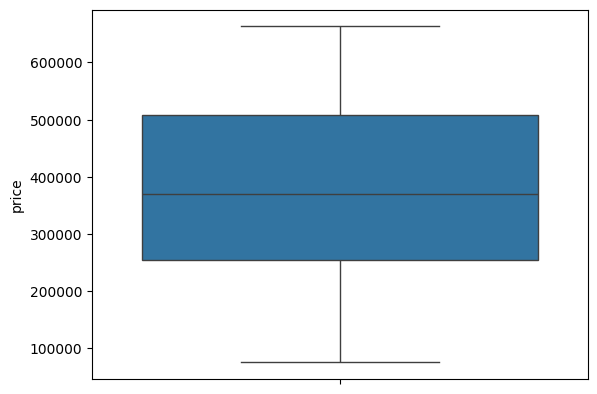

In [ ]:
sns.boxplot(df['price'])
plt.show()

In [ ]:
X=df.drop('price',axis=1)
y=df['price']

In [ ]:
X.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'parking_spaces'], dtype='object')

In [ ]:
X

,area_sqft,bedrooms,bathrooms,age_years,parking_spaces
0,3774,4,2,3,2
1,1460,5,2,8,0
2,1894,2,2,5,1
3,1730,4,4,1,2
4,1695,2,3,16,2
...,...,...,...,...,...
495,1476,2,2,19,1
496,1591,3,2,28,1
497,3531,5,4,11,1
498,646,4,1,6,0


In [ ]:
y

,price
0,611362
1,265630
2,323350
3,324974
4,277830
...,...
495,224037
496,220094
497,599515
498,115214


In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Train Lineat Regression Model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
#Train Random Forest Model
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
#Predicitions
lr_pred=lr.predict(X_test)
rf_pred=rf.predict(X_test)

In [ ]:
lr_pred

array([261663.42049304, 605416.00580475, 214872.11066796, 239865.1592484 ,
       173031.30766849, 584456.12258222, 629721.65253799, 172718.96205587,
       332279.88503447, 186145.26941877, 308755.43543782, 413943.05812145,
       110426.15838516, 379239.87143299, 373018.92695934, 234243.15324133,
       223541.46112895, 470259.82274342, 587290.5992717 , 605828.91544776,
       519574.95118112, 114594.22915082, 364147.63322103, 201439.2937774 ,
       571039.50439105, 265204.10447219, 596255.21393413, 249359.98336411,
       478904.76339555,  81069.27739331, 404964.47421688, 566032.60354531,
       603415.27807133, 490433.50930759, 316725.30835297, 304692.42898912,
       264467.73990246, 238504.56627427, 360318.1163302 , 556248.70495859,
       240873.12952451, 305206.04111402, 476701.34090862, 561510.80952859,
       176880.07837061, 269621.64930731, 631800.79501089, 338665.97732493,
       597637.05841621, 462566.13414033, 439210.1977145 , 605521.62625165,
       133019.99185343, 2

In [ ]:
y_test

,price
361,269226
73,599963
374,211979
155,237545
104,178678
...,...
347,525135
86,153765
75,329890
438,589349


In [ ]:
X_test

,area_sqft,bedrooms,bathrooms,age_years,parking_spaces
361,1818,1,3,26,2
73,3752,5,1,10,0
374,1162,2,2,4,2
155,1470,3,1,13,1
104,979,2,2,5,0
...,...,...,...,...,...
347,3469,4,2,27,1
86,801,4,3,7,0
75,2185,3,3,29,1
438,3775,3,2,28,1


In [ ]:
#Model Evaluation
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
print("LR RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("LR R2 Score:", r2_score(y_test, lr_pred))

LR RMSE: 14651.686666093292
LR R2 Score: 0.989939933518724


In [ ]:
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("RF R2 Score:", r2_score(y_test, rf_pred))

RF RMSE: 20420.730351277103
RF R2 Score: 0.980458038781462
